# Implementing QAOA in Pennylane 

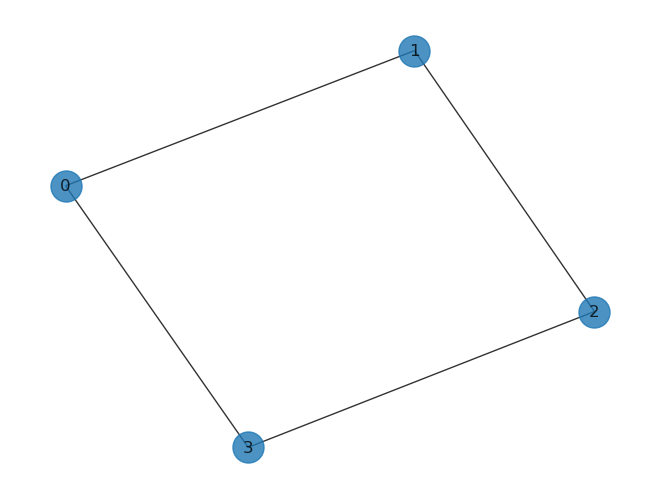

In [126]:
import networkx as nx
graph = nx.Graph()
graph.add_nodes_from([0, 1, 2, 3])
graph.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])
nx.draw(graph, with_labels=True, alpha=0.8, node_size=500)

In [128]:
import pennylane as qml 
from pennylane import numpy as np 

np.random.seed(42)

## Build the unitary operators
I set n_wires to represent the number of qubits (vertices) and build the unitary operators.  
1. $U_M$ operators act on individual wires.
2. $U_C$ operators act on wires whose corresponding vertices are joined by an edge in the graph.

In [132]:
n_wires = 4 #number of qubits(vertices)
graph = [(0, 1), (0, 3), (1, 2), (2, 3)] 

# Mixer unitary operator U_M with parameter beta
def U_M(beta):
    for wire in range(n_wires):   # Loop over all qubits in the circuit
        qml.RX(2*beta, wires= wire)  # Apply an RX rotation to each qubit
                                    # Angle = 2 * beta (standard in QAOA mixer implementation)
                                    # This operation mixes the amplitudes of computational basis states
                                    # and allows the algorithm to explore different solutions


# Cost unitary operator U_C with parameter gamma
def U_C(gamma):
    for edge in graph:   # Loop over all edges of the graph
                                # Each edge contributes to the Max-Cut cost Hamiltonian
        
        qml.CNOT(wires=edge)    # Apply a CNOT gate
                                # This entangles the two qubits corresponding to the edge (i, j)
        
        qml.RZ(gamma, wires=edge[1])   # Apply a Z-rotation on the second qubit of the edge
                                        # The angle gamma encodes the cost Hamiltonian phase
        
        qml.CNOT(wires=edge)    # Apply another CNOT to undo the entanglement
                                # Together these gates implement the two-qubit interaction term
                                # exp(-i * gamma * Z_i Z_j) used in QAOA

In [134]:
# Maps a sampled bitstring to an integer representing the state of multiple qubits
def bitstring_to_int(bit_string_sample):
    return int(2 ** np.arange(len(bit_string_sample)) @ bit_string_sample[::-1])

In [136]:
# Create a quantum device with 4 qubits.
dev = qml.device("lightning.qubit", wires = n_wires)

In [138]:
@qml.set_shots(20)  # Set the number of shots (samples) for measurement
@qml.qnode(dev) # Define a QNode (quantum node) on the chosen device

def circuit (gammas, betas, return_samples = False):
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)

        """
    Args:
        gammas: list of gamma parameters for cost unitary U_C
        betas: list of beta parameters for mixer unitary U_B
        return_samples: if True, return sampled bitstrings; else return expectation value
    
    Returns:
        Either sampled bitstrings (for analyzing cuts) or expectation value of cost Hamiltonian
    """

    for gamma, beta in zip(gammas, betas):
        U_C(gamma)  # cost Hamiltonian unitary
        U_M(beta)  # mixer Hamiltonian unitary

    if return_samples:
        return qml.sample()

    # during the optimization phase we are evaluating the objective using expval
    C = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in graph))
    return qml.expval(C) 

#During optimization, return expectation value of cost Hamiltonian
# Construct cost Hamiltonian C as sum of Z_i Z_j terms for each edge
def objective(params):
    return -0.5 * (len(graph) - circuit(*params))

In [148]:
def qaoa_maxcut(n_layers):
    """
    Perform QAOA for Max-Cut on a given graph.
    
    Args:
        n_layers: Number of QAOA layers (p)
    
    Returns:
        Tuple of:
            - Final objective value
            - List of sampled bitstrings (as integers)
    """
    
    print(f"\np={n_layers:d}")  # Print the current QAOA layer depth

    # Initialize parameters near zero
    # We have 2 parameter sets: gammas and betas
    # Shape: (2, n_layers)
    # requires_grad=True allows PennyLane to compute gradients
    init_params = 0.01 * np.random.rand(2, n_layers, requires_grad=True)

    # Initialize classical optimizer
    # Adagrad is an adaptive gradient descent method
    opt = qml.AdagradOptimizer(stepsize=0.5)

    # Optimization loop
    params = init_params.copy()
    steps = 30  # Number of classical optimization steps
    for i in range(steps):
        # Update parameters using the classical optimizer
        params = opt.step(objective, params)
        
        # Print intermediate objective values every 5 steps
        if (i + 1) % 5 == 0:
            # Negate because 'objective' is defined as negative for minimization
            print(f"Objective after step {i+1:3d}: {-objective(params): .7f}")

    # Sample bitstrings from the optimized QAOA state
    # Set QNode to sample 100 times
    bitstrings = qml.set_shots(circuit, shots=100)(*params, return_samples=True)

    # Convert bitstrings to integers for easier counting
    sampled_ints = [bitstring_to_int(string) for string in bitstrings]

    # Find the most frequently sampled bitstring
    counts = np.bincount(np.array(sampled_ints))
    most_freq_bit_string = np.argmax(counts)

    # results
    print(f"Optimized parameters:\ngamma: {params[0]}\nbeta:  {params[1]}")
    print(f"Most frequently sampled bit string is: {most_freq_bit_string:04b}")

    # Step 8: Return final objective value and list of sampled integers
    return -objective(params), sampled_ints


# Run QAOA for layer depth p=1
int_sample = qaoa_maxcut(1)[1]  # bitstrings as integers for p=1


p=1
Objective after step   5:  2.9000000
Objective after step  10:  3.0000000
Objective after step  15:  2.9000000
Objective after step  20:  3.2000000
Objective after step  25:  3.0000000
Objective after step  30:  3.1000000
Optimized parameters:
gamma: [-0.82519356]
beta:  [0.37301063]
Most frequently sampled bit string is: 0101


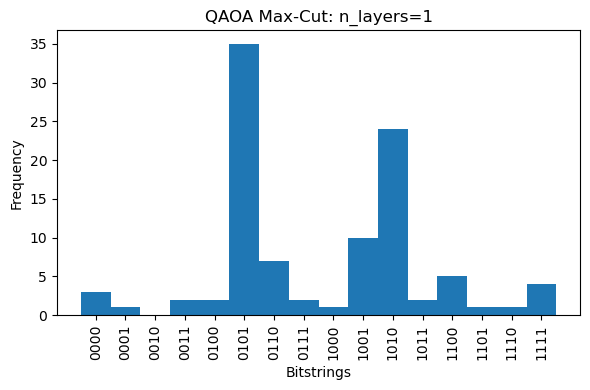

In [150]:
import matplotlib.pyplot as plt

# Prepare x-axis: integers 0–15 for 4 qubits
xticks = range(0, 16)
# Convert integers to 4-bit binary strings
xtick_labels = [format(x, "04b") for x in xticks]
# Histogram bins for proper alignment
bins = np.arange(0, 17) - 0.5

# Create figure
plt.figure(figsize=(6, 4))

# Plot histogram for p=1 (one layer)
plt.title("QAOA Max-Cut: n_layers=1")
plt.xlabel("Bitstrings")
plt.ylabel("Frequency")
plt.xticks(xticks, xtick_labels, rotation="vertical")
plt.hist(int_samples1, bins=bins)

plt.tight_layout()
plt.show()